# Лабораторная работа: Задача о многоруком бандите

**Дисциплиина:** Распознавание образов и индуктивное моделирование (РОИМ)
**Курс:** Обучение с подкреплением (Reinforcement Learning)

## Цель работы
Реализовать и сравнить основные стратегии решения задачи о многоруком бандите:

- Жадная стратегия (Greedy)
- ε-жадная стратегия (Epsilon-Greedy)
- Pursuit
- Reinforcement Comparison
- UCB (Upper Confidence Bound)

## Что нужно сделать
1. Реализовать среду многорукого бандита.
2. Реализовать каждый алгоритм выбора действий.
3. Провести эксперименты и сравнить методы:
   - среднюю награду,
   - долю выбора оптимального действия,
   - чувствительность к параметрам.
4. Сделать выводы по результатам.

---
## Теоретический контекст

Задача о многоруком бандите (multi-armed bandit) — это упрощённая постановка задачи исследования/эксплуатации (exploration vs exploitation).

У нас есть $k$ действий (рычагов автомата). Для каждого действия существует неизвестное распределение наград.
На каждом шаге агент:
1. выбирает действие $A_t$,
2. получает награду $R_t$,
3. обновляет свою оценку качества действия.

Основная цель — максимизировать суммарную награду.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from abc import ABC, abstractmethod
from IPython.display import display

RNG = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 12


def random_argmax(values):
    """
    Возвращает случайный индекс среди всех максимумов.

    Улучшение по сравнению с np.argmax: при равенстве np.argmax всегда
    возвращает первый индекс, из-за чего агент с нулевыми начальными
    оценками искусственно предпочитал бы действие 0.
    """
    values = np.asarray(values)
    max_value = np.max(values)
    candidates = np.flatnonzero(np.isclose(values, max_value))
    return RNG.choice(candidates)


def moving_average(x, window=20):
    """Сглаживание только для визуализации."""
    x = np.asarray(x)
    if window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


# 1. Среда многорукого бандита

Будем использовать классическую стационарную постановку:
- Есть $k$ действий.
- Для каждого действия $a$ существует истинное среднее значение награды $q_*(a)$.
- На каждом шаге награда генерируется как:

$$
R_t \sim \mathcal{N}(q_*(A_t), 1)
$$

Истинные значения $q_*(a)$ случайно генерируются один раз в начале эпизода:

$$
q_*(a) \sim \mathcal{N}(0, 1)
$$

In [2]:
class KArmedBandit:
    def __init__(self, k=10, reward_std=1.0):
        self.k = k
        self.reward_std = reward_std
        self.q_true = RNG.normal(loc=0.0, scale=1.0, size=k)
        self.optimal_action = np.argmax(self.q_true)

    def step(self, action):
        reward = RNG.normal(loc=self.q_true[action], scale=self.reward_std)
        return reward

# 2. Базовый интерфейс агента

Каждый алгоритм должен уметь:
- выбрать действие (`select_action`)
- обновить внутреннее состояние (`update`)

In [3]:
class BanditAgent(ABC):
    def __init__(self, k):
        self.k = k

    @abstractmethod
    def select_action(self):
        pass

    @abstractmethod
    def update(self, action, reward):
        pass

# 3. Жадная стратегия (Greedy)

Жадная стратегия всегда выбирает действие с максимальной текущей оценкой:

$$
A_t = \arg\max_a Q_t(a)
$$

где:
- $Q_t(a)$ — текущая оценка среднего вознаграждения для действия $a$.

## Проблема
Жадная стратегия **не исследует** новые действия.
Если на ранних шагах случайно были получены неудачные награды, алгоритм может "застрять" на неоптимальном действии.

## Задание
Реализуйте класс `GreedyAgent`.

Для обновления использовать **инкрементальное среднее**:

$$
Q_{n+1} = Q_n + \frac{1}{N}(R - Q_n)
$$

In [4]:
class GreedyAgent(BanditAgent):
    def __init__(self, k):
        super().__init__(k)
        self.Q = np.zeros(k)
        self.N = np.zeros(k, dtype=int)

    def select_action(self):
        return random_argmax(self.Q)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


# 4. ε-жадная стратегия (Epsilon-Greedy)

Идея:
- с вероятностью $1 - \varepsilon$ выбираем лучшее по текущей оценке действие,
- с вероятностью $\varepsilon$ выбираем случайное действие.

Формально:

$$
A_t =
\begin{cases}
\arg\max_a Q_t(a), & \text{с вероятностью } 1 - \varepsilon \\
\text{случайное действие}, & \text{с вероятностью } \varepsilon
\end{cases}
$$

## Задание
Реализуйте класс `EpsilonGreedyAgent`.

In [5]:
class EpsilonGreedyAgent(BanditAgent):
    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon
        self.Q = np.zeros(k)
        self.N = np.zeros(k, dtype=int)

    def select_action(self):
        if RNG.random() < self.epsilon:
            return RNG.integers(self.k)
        return random_argmax(self.Q)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


# 5. Pursuit

В pursuit-алгоритме агент хранит:
- оценки действий $Q(a)$,
- вероятности выбора действий $\pi(a)$.

На каждом шаге:
1. выбирается действие согласно распределению $\pi$;
2. обновляются оценки $Q$;
3. определяется текущее лучшее действие:
   $$
   a^* = \arg\max_a Q(a)
   $$
4. вероятности действий сдвигаются в сторону лучшего действия:

$$
\pi_{t+1}(a) =
\begin{cases}
\pi_t(a) + \beta (1 - \pi_t(a)), & a = a^* \\
(1 - \beta)\pi_t(a), & a \ne a^*
\end{cases}
$$

## Задание
Реализуйте `PursuitAgent`.

In [6]:
class PursuitAgent(BanditAgent):
    def __init__(self, k, beta=0.05):
        super().__init__(k)
        self.beta = beta
        self.Q = np.zeros(k)
        self.N = np.zeros(k, dtype=int)
        self.pi = np.ones(k) / k

    def select_action(self):
        return RNG.choice(self.k, p=self.pi)

    def update(self, action, reward):
        # 1. Обновляем оценку выбранного действия через инкрементальное среднее.
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

        # 2. Находим текущее лучшее действие.
        best_action = random_argmax(self.Q)

        # 3. Сдвигаем распределение вероятностей в сторону лучшего действия.
        self.pi *= (1 - self.beta)
        self.pi[best_action] += self.beta

        # Небольшая численная страховка: вероятности должны суммироваться в 1.
        self.pi = np.clip(self.pi, 0, 1)
        self.pi /= self.pi.sum()


# 6. Reinforcement Comparison

В этом методе агент хранит:
- **предпочтения** действий $H(a)$,
- **базовый уровень награды** (baseline) $\bar{R}$.

Вероятности действий определяются через softmax:

$$
\pi(a) = \frac{e^{H(a)}}{\sum_b e^{H(b)}}
$$

После получения награды $R_t$:
1. обновляется baseline:
$$
\bar{R}_{t+1} = \bar{R}_t + \alpha_r (R_t - \bar{R}_t)
$$

2. обновляются предпочтения выбранного действия:
$$
H_{t+1}(A_t) = H_t(A_t) + \alpha_h (R_t - \bar{R}_t)(1 - \pi(A_t))
$$

3. обновляются предпочтения остальных действий:
$$
H_{t+1}(a) = H_t(a) - \alpha_h (R_t - \bar{R}_t)\pi(a), \quad a \ne A_t
$$

## Задание
Реализуйте `ReinforcementComparisonAgent`.

In [7]:
class ReinforcementComparisonAgent(BanditAgent):
    def __init__(self, k, alpha_h=0.1, alpha_r=0.1):
        super().__init__(k)
        self.alpha_h = alpha_h
        self.alpha_r = alpha_r
        self.H = np.zeros(k)
        self.avg_reward = 0.0

    def _softmax(self):
        # Numerically stable softmax: вычитаем максимум, чтобы избежать overflow.
        z = self.H - np.max(self.H)
        exp_z = np.exp(z)
        return exp_z / exp_z.sum()

    def select_action(self):
        pi = self._softmax()
        return RNG.choice(self.k, p=pi)

    def update(self, action, reward):
        # Вероятности нужны до обновления предпочтений.
        pi = self._softmax()

        # Используем старый baseline для оценки advantage.
        old_avg_reward = self.avg_reward
        advantage = reward - old_avg_reward

        # Обновляем baseline.
        self.avg_reward += self.alpha_r * advantage

        # Векторная форма формул:
        # H(a) += alpha_h * advantage * (1{a=A_t} - pi(a))
        one_hot = np.zeros(self.k)
        one_hot[action] = 1.0
        self.H += self.alpha_h * advantage * (one_hot - pi)


# 7. UCB (Upper Confidence Bound)

UCB выбирает действие по правилу:

$$
A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right]
$$

где:
- $Q_t(a)$ — текущая оценка действия,
- $N_t(a)$ — сколько раз действие уже выбиралось,
- $t$ — номер шага,
- $c$ — коэффициент исследования.

## Важная деталь
Если действие ещё ни разу не выбиралось (`N(a)=0`), его обычно выбирают в первую очередь.

## Задание
Реализуйте `UCBAgent`.

In [8]:
class UCBAgent(BanditAgent):
    def __init__(self, k, c=2.0):
        super().__init__(k)
        self.c = c
        self.Q = np.zeros(k)
        self.N = np.zeros(k, dtype=int)
        self.t = 0

    def select_action(self):
        self.t += 1

        # Сначала пробуем каждое действие хотя бы один раз.
        untried_actions = np.flatnonzero(self.N == 0)
        if len(untried_actions) > 0:
            return RNG.choice(untried_actions)

        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return random_argmax(ucb_values)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


# 8. Запуск одного эпизода

In [9]:
def run_episode(
    agent_class,
    agent_kwargs=None,
    k=10,
    steps=1000,
    env_class=KArmedBandit,
    env_kwargs=None
):
    if agent_kwargs is None:
        agent_kwargs = {}
    if env_kwargs is None:
        env_kwargs = {}

    env = env_class(k=k, **env_kwargs)
    agent = agent_class(k=k, **agent_kwargs)

    rewards = np.zeros(steps)
    optimal_actions = np.zeros(steps)

    for t in range(steps):
        action = agent.select_action()
        reward = env.step(action)
        agent.update(action, reward)

        rewards[t] = reward
        optimal_actions[t] = 1 if action == env.optimal_action else 0

    return rewards, optimal_actions


# 9. Усреднение по многим запускам

In [10]:
def evaluate_agent(
    agent_class,
    agent_kwargs=None,
    runs=200,
    k=10,
    steps=1000,
    env_class=KArmedBandit,
    env_kwargs=None
):
    if agent_kwargs is None:
        agent_kwargs = {}
    if env_kwargs is None:
        env_kwargs = {}

    all_rewards = np.zeros((runs, steps))
    all_optimal = np.zeros((runs, steps))

    for run in range(runs):
        rewards, optimal = run_episode(
            agent_class=agent_class,
            agent_kwargs=agent_kwargs,
            k=k,
            steps=steps,
            env_class=env_class,
            env_kwargs=env_kwargs
        )
        all_rewards[run] = rewards
        all_optimal[run] = optimal

    avg_rewards = all_rewards.mean(axis=0)
    optimal_action_rate = all_optimal.mean(axis=0)

    return avg_rewards, optimal_action_rate


def summarize_results(results, tail=100):
    """Таблица качества: средние значения на последних tail шагах."""
    rows = []
    for name, (avg_rewards, optimal_rate) in results.items():
        rows.append({
            "agent": name,
            f"avg_reward_last_{tail}": avg_rewards[-tail:].mean(),
            f"optimal_action_rate_last_{tail}": optimal_rate[-tail:].mean()
        })
    return (
        pd.DataFrame(rows)
        .sort_values(f"avg_reward_last_{tail}", ascending=False)
        .reset_index(drop=True)
    )


def plot_comparison(results, title_prefix="", smooth_window=20):
    """Два стандартных графика: награда и доля оптимального действия."""
    plt.figure()
    for name, (avg_rewards, _) in results.items():
        plt.plot(moving_average(avg_rewards, smooth_window), label=name)
    plt.xlabel("Шаг")
    plt.ylabel("Средняя награда")
    plt.title(f"{title_prefix}: средняя награда")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    for name, (_, optimal_rate) in results.items():
        plt.plot(moving_average(optimal_rate, smooth_window), label=name)
    plt.xlabel("Шаг")
    plt.ylabel("Доля выбора оптимального действия")
    plt.title(f"{title_prefix}: оптимальное действие")
    plt.legend()
    plt.grid(True)
    plt.show()


# 10. Эксперимент 1: сравнение Greedy, ε-Greedy и UCB

## Задание
После реализации агентов:
1. Сравните:
   - `GreedyAgent`
   - `EpsilonGreedyAgent(epsilon=0.1)`
   - `EpsilonGreedyAgent(epsilon=0.01)`
   - `UCBAgent(c=2.0)`

2. Постройте два графика:
   - средняя награда по шагам,
   - доля выбора оптимального действия.

3. Ответьте:
   - Почему чисто жадная стратегия обычно проигрывает?
   - Чем отличаются `epsilon=0.1` и `epsilon=0.01`?
   - Почему UCB часто работает лучше на ранних шагах?

In [11]:
# Для быстрой проверки стоит 50 запусков. Если нужно более гладкие графики,
# можно увеличить RUNS до 200, как в классической постановке эксперимента.
RUNS = 200
STEPS = 1000
K = 10

configs_exp1 = [
    ("Greedy", GreedyAgent, {}),
    ("Eps=0.1", EpsilonGreedyAgent, {"epsilon": 0.1}),
    ("Eps=0.01", EpsilonGreedyAgent, {"epsilon": 0.01}),
    ("UCB c=2.0", UCBAgent, {"c": 2.0}),
]

results_exp1 = {}
for name, cls, kwargs in configs_exp1:
    avg_rewards, optimal_rate = evaluate_agent(cls, kwargs, runs=RUNS, k=K, steps=STEPS)
    results_exp1[name] = (avg_rewards, optimal_rate)

summary_exp1 = summarize_results(results_exp1, tail=100)
display(summary_exp1)


,agent,avg_reward_last_100,optimal_action_rate_last_100
0,UCB c=2.0,1.498694,0.86660
1,Eps=0.1,1.393990,0.77965
2,Eps=0.01,1.268613,0.56725
3,Greedy,1.038315,0.37000


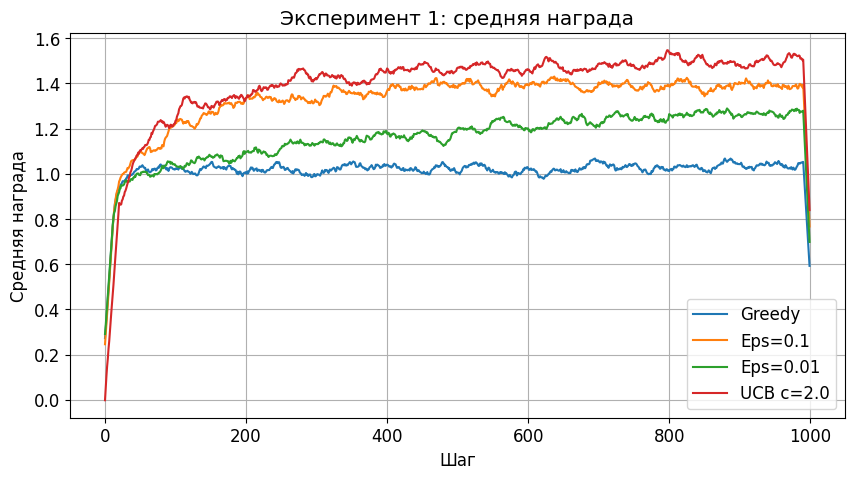

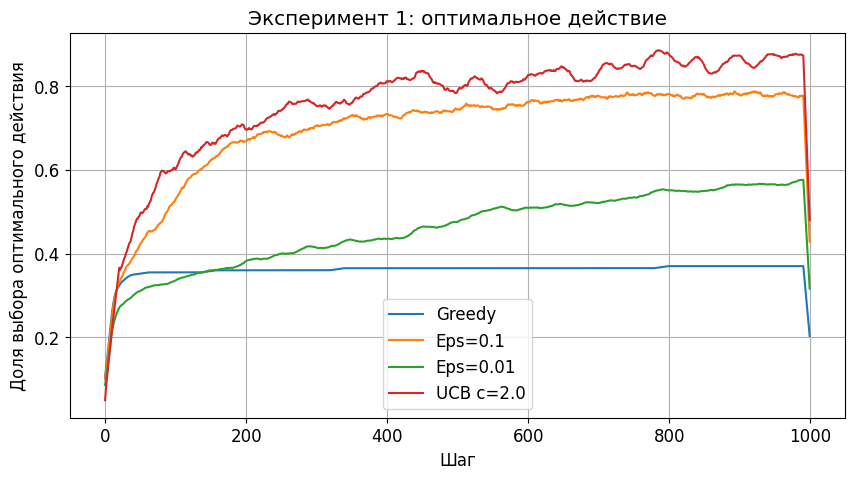

In [12]:
plot_comparison(results_exp1, title_prefix="Эксперимент 1", smooth_window=20)


## Выводы по Experiment 1

Чисто жадная стратегия обычно проигрывает, потому что не исследует действия после начальных случайных оценок. Если в начале ей не повезло, она может застрять на неоптимальном рычаге.

$\varepsilon=0.1$ исследует заметно активнее и чаще быстрее находит оптимальное действие. $\varepsilon=0.01$ исследует осторожнее: на поздних шагах он меньше тратит действий на случайность, но в начале может дольше оставаться при ошибочной оценке.

UCB часто силён на ранних шагах, потому что добавляет бонус неопределённости к редко выбранным действиям. Это делает исследование направленным, а не полностью случайным.

# 11. Эксперимент 2: Pursuit

## Задание
1. Реализуйте `PursuitAgent`.
2. Сравните несколько значений параметра `beta`:
   - `beta = 0.01`
   - `beta = 0.05`
   - `beta = 0.1`

3. Сравните с `EpsilonGreedyAgent(epsilon=0.1)`.

## Вопросы
- Как влияет `beta` на скорость "схлопывания" распределения вероятностей?
- Что происходит при слишком большом `beta`?

,agent,avg_reward_last_100,optimal_action_rate_last_100
0,Pursuit beta=0.01,1.454968,0.90835
1,Pursuit beta=0.05,1.447408,0.72995
2,Eps=0.1,1.374845,0.79255
3,Pursuit beta=0.1,1.259460,0.57500


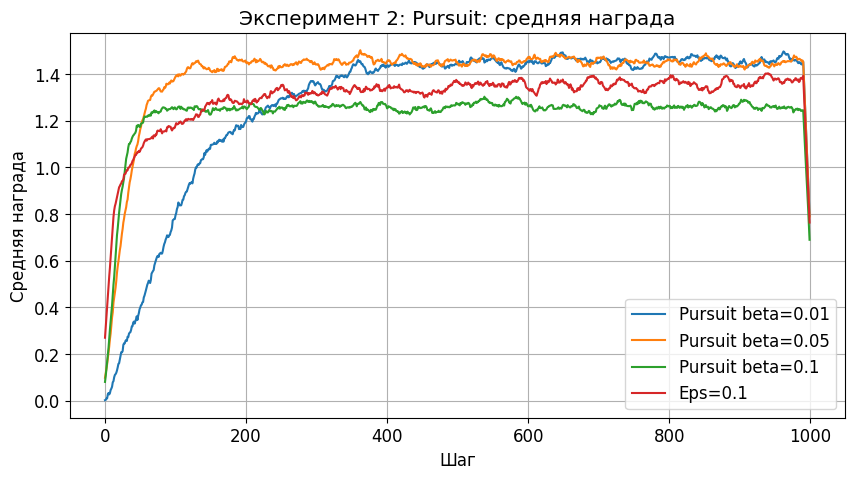

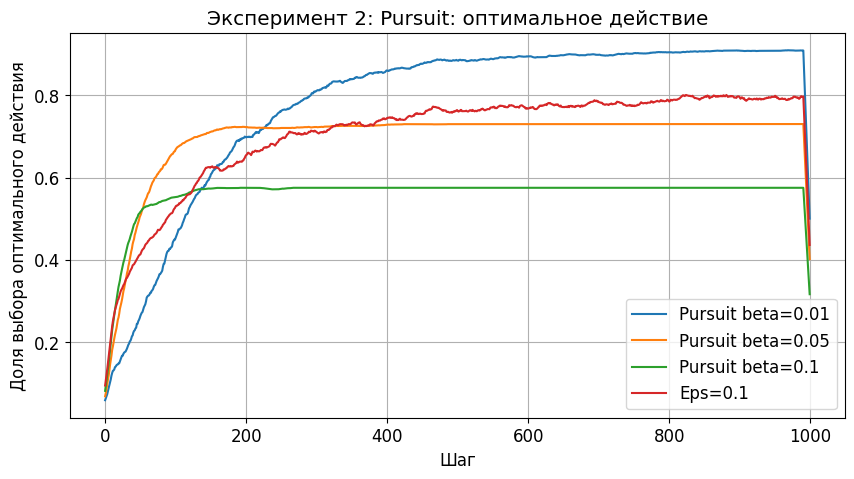

In [13]:
configs_pursuit = [
    ("Pursuit beta=0.01", PursuitAgent, {"beta": 0.01}),
    ("Pursuit beta=0.05", PursuitAgent, {"beta": 0.05}),
    ("Pursuit beta=0.1", PursuitAgent, {"beta": 0.1}),
    ("Eps=0.1", EpsilonGreedyAgent, {"epsilon": 0.1}),
]

results_pursuit = {}
for name, cls, kwargs in configs_pursuit:
    avg_rewards, optimal_rate = evaluate_agent(cls, kwargs, runs=RUNS, k=K, steps=STEPS)
    results_pursuit[name] = (avg_rewards, optimal_rate)

summary_pursuit = summarize_results(results_pursuit, tail=100)
display(summary_pursuit)

plot_comparison(results_pursuit, title_prefix="Эксперимент 2: Pursuit", smooth_window=20)


## Выводы по Experiment 2

Параметр $\beta$ управляет тем, насколько быстро вероятности выбора действий смещаются к текущему лучшему действию. Малое значение делает обучение устойчивым, но медленным. Большое значение быстрее концентрирует вероятность на одном действии, но повышает риск рано «схлопнуться» на неоптимальном варианте из-за случайного шума в начальных наградах.

# 12. Эксперимент 3: Reinforcement Comparison

## Задание
1. Реализуйте `ReinforcementComparisonAgent`.
2. Сравните несколько настроек:
   - `alpha_h = 0.1, alpha_r = 0.1`
   - `alpha_h = 0.1, alpha_r = 0.01`
   - `alpha_h = 0.01, alpha_r = 0.1`

3. Сравните с `PursuitAgent` и `UCB`.

## Вопросы
- Какую роль играет baseline $\bar{R}$?
- Почему обновление зависит от $(R_t - \bar{R}_t)$, а не просто от $R_t$?

,agent,avg_reward_last_100,optimal_action_rate_last_100
0,RC ah=0.1 ar=0.1,1.532488,0.85610
1,RC ah=0.1 ar=0.01,1.475355,0.85915
2,UCB c=2.0,1.464183,0.83250
3,Pursuit beta=0.05,1.446631,0.71500
4,RC ah=0.01 ar=0.1,0.998148,0.49940


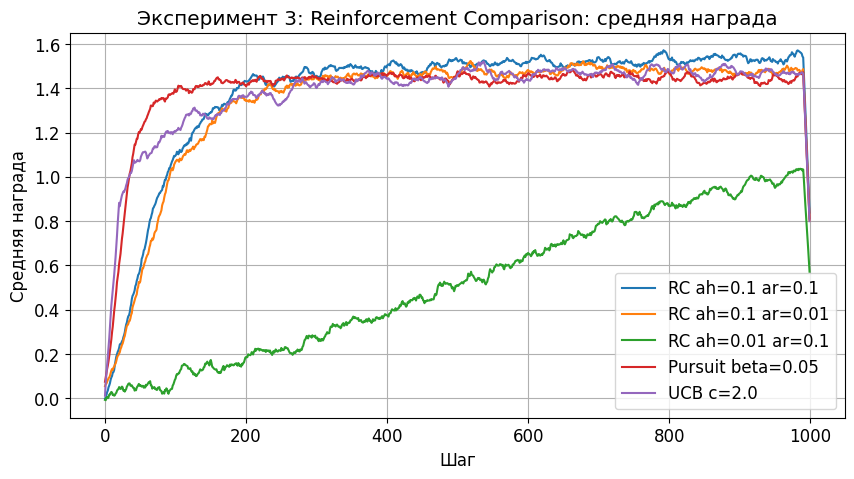

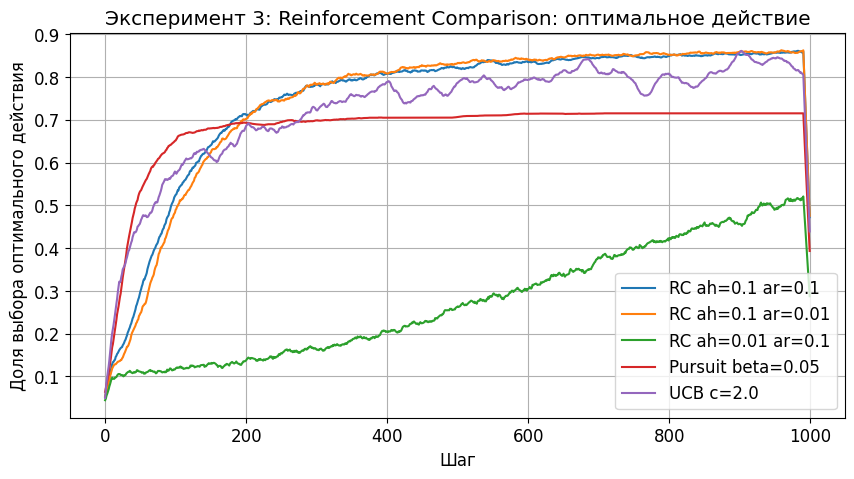

In [14]:
configs_rc = [
    ("RC ah=0.1 ar=0.1", ReinforcementComparisonAgent, {"alpha_h": 0.1, "alpha_r": 0.1}),
    ("RC ah=0.1 ar=0.01", ReinforcementComparisonAgent, {"alpha_h": 0.1, "alpha_r": 0.01}),
    ("RC ah=0.01 ar=0.1", ReinforcementComparisonAgent, {"alpha_h": 0.01, "alpha_r": 0.1}),
    ("Pursuit beta=0.05", PursuitAgent, {"beta": 0.05}),
    ("UCB c=2.0", UCBAgent, {"c": 2.0}),
]

results_rc = {}
for name, cls, kwargs in configs_rc:
    avg_rewards, optimal_rate = evaluate_agent(cls, kwargs, runs=RUNS, k=K, steps=STEPS)
    results_rc[name] = (avg_rewards, optimal_rate)

summary_rc = summarize_results(results_rc, tail=100)
display(summary_rc)

plot_comparison(results_rc, title_prefix="Эксперимент 3: Reinforcement Comparison", smooth_window=20)


## Выводы по Experiment 3

Baseline $\bar{R}$ в Reinforcement Comparison нужен как точка сравнения. Агент усиливает выбранное действие не просто за большую награду, а за награду, которая оказалась выше ожидаемого уровня.

Обновление через $(R_t - \bar{R}_t)$ полезно, потому что одинаковая абсолютная награда может быть хорошей в одной задаче и плохой в другой. Baseline делает сигнал обучения относительным и обычно снижает дисперсию обновлений. Если $\alpha_r$ слишком мал, baseline медленно адаптируется; если слишком велик, он становится шумным.

# 13. Обязательная часть лабораторной

## Нужно сдать:
1. Реализацию классов:
   - `GreedyAgent`
   - `EpsilonGreedyAgent`
   - `PursuitAgent`
   - `ReinforcementComparisonAgent`
   - `UCBAgent`

2. Графики:
   - Средняя награда
   - Доля выбора оптимального действия

3. Таблицу финальных результатов (например, средняя награда на последних 100 шагах)

4. Краткий отчёт:
   - Какой метод оказался лучшим?
   - Как параметры влияют на поведение?
   - Какой баланс exploration/exploitation у каждого метода?

# 14. Дополнительное задание (повышенной сложности): нестационарный бандит

Измените среду так, чтобы истинные значения действий менялись со временем:

$$
q_{t+1}(a) = q_t(a) + \mathcal{N}(0, \sigma^2)
$$

## Вопросы
1. Какие методы начинают работать хуже?
2. Почему sample-average обновление становится неидеальным?
3. Попробуйте заменить его на обновление с постоянным шагом:

$$
Q_{t+1}(a) = Q_t(a) + \alpha (R_t - Q_t(a))
$$

In [15]:
class NonStationaryKArmedBandit:
    def __init__(self, k=10, reward_std=1.0, drift_std=0.01):
        self.k = k
        self.reward_std = reward_std
        self.drift_std = drift_std
        self.q_true = RNG.normal(loc=0.0, scale=1.0, size=k)
        self.optimal_action = np.argmax(self.q_true)

    def step(self, action):
        reward = RNG.normal(loc=self.q_true[action], scale=self.reward_std)

        # Дрейф истинных значений
        self.q_true += RNG.normal(loc=0.0, scale=self.drift_std, size=self.k)
        self.optimal_action = np.argmax(self.q_true)

        return reward

,agent,avg_reward_last_100,optimal_action_rate_last_100
0,UCB c=2.0,1.534247,0.83415
1,Eps=0.1 alpha=0.1,1.393735,0.72900
2,Eps=0.1 sample-average,1.389578,0.76195
3,Greedy alpha=0.1,1.298392,0.48395
4,Eps=0.1 alpha=0.01,1.086779,0.41090


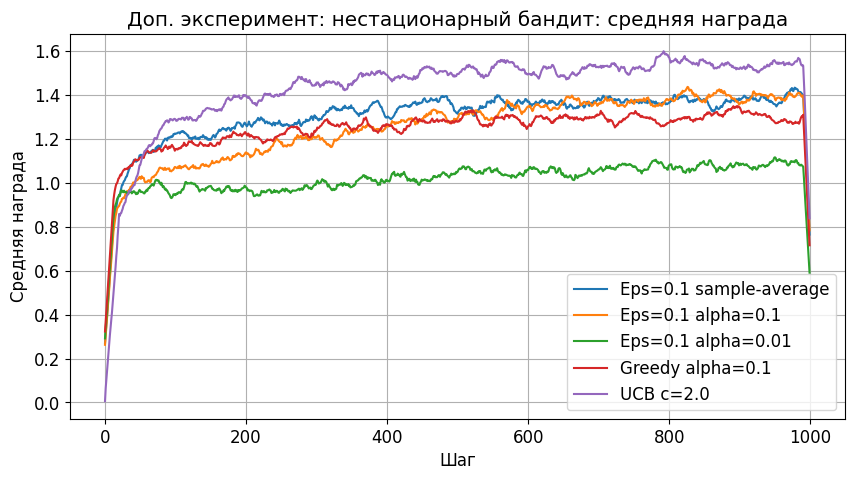

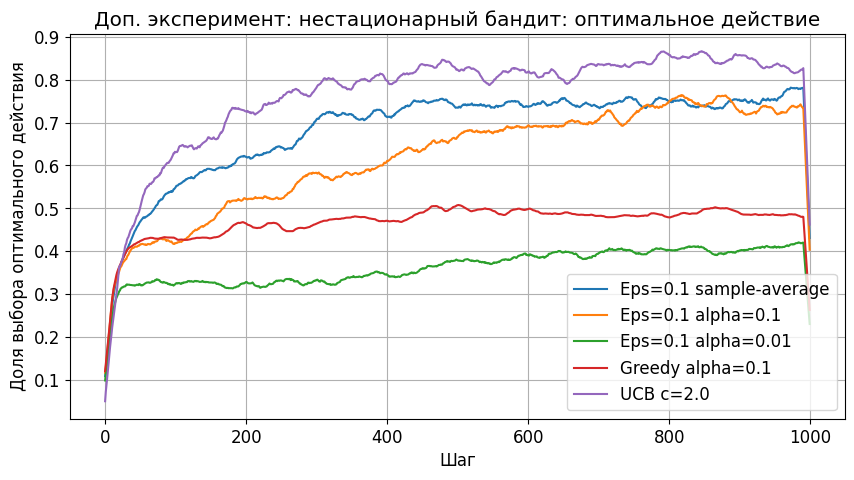

In [16]:
class ConstantStepGreedyAgent(BanditAgent):
    """Жадный агент с постоянным шагом alpha для нестационарной среды."""
    def __init__(self, k, alpha=0.1):
        super().__init__(k)
        self.alpha = alpha
        self.Q = np.zeros(k)

    def select_action(self):
        return random_argmax(self.Q)

    def update(self, action, reward):
        self.Q[action] += self.alpha * (reward - self.Q[action])


class ConstantStepEpsilonGreedyAgent(BanditAgent):
    """ε-жадный агент с постоянным шагом alpha."""
    def __init__(self, k, epsilon=0.1, alpha=0.1):
        super().__init__(k)
        self.epsilon = epsilon
        self.alpha = alpha
        self.Q = np.zeros(k)

    def select_action(self):
        if RNG.random() < self.epsilon:
            return RNG.integers(self.k)
        return random_argmax(self.Q)

    def update(self, action, reward):
        self.Q[action] += self.alpha * (reward - self.Q[action])


configs_nonstationary = [
    ("Eps=0.1 sample-average", EpsilonGreedyAgent, {"epsilon": 0.1}),
    ("Eps=0.1 alpha=0.1", ConstantStepEpsilonGreedyAgent, {"epsilon": 0.1, "alpha": 0.1}),
    ("Eps=0.1 alpha=0.01", ConstantStepEpsilonGreedyAgent, {"epsilon": 0.1, "alpha": 0.01}),
    ("Greedy alpha=0.1", ConstantStepGreedyAgent, {"alpha": 0.1}),
    ("UCB c=2.0", UCBAgent, {"c": 2.0}),
]

results_nonstationary = {}
for name, cls, kwargs in configs_nonstationary:
    avg_rewards, optimal_rate = evaluate_agent(
        cls,
        kwargs,
        runs=RUNS,
        k=K,
        steps=STEPS,
        env_class=NonStationaryKArmedBandit,
        env_kwargs={"drift_std": 0.01}
    )
    results_nonstationary[name] = (avg_rewards, optimal_rate)

summary_nonstationary = summarize_results(results_nonstationary, tail=100)
display(summary_nonstationary)

plot_comparison(
    results_nonstationary,
    title_prefix="Доп. эксперимент: нестационарный бандит",
    smooth_window=20
)


## Выводы по дополнительному заданию: нестационарный бандит

В нестационарной среде истинные значения действий дрейфуют, поэтому старые награды становятся менее релевантными. Из-за этого sample-average обновление хуже адаптируется: чем больше наблюдений накоплено, тем меньше влияние новой награды.

Постоянный шаг $\alpha$ решает эту проблему частично: новая награда всегда имеет заметный вес, поэтому агент быстрее подстраивается под изменения. Слишком большой $\alpha$ может сделать оценки шумными, а слишком маленький — снова замедлить адаптацию.

# 15. Итоговые вопросы для отчёта

1. Почему жадная стратегия обычно уступает методам с исследованием?
2. Как $\varepsilon$ влияет на поведение $\varepsilon$-жадного алгоритма?
3. Чем UCB отличается от случайного исследования?
4. Почему pursuit можно интерпретировать как "постепенное сосредоточение вероятности" на лучшем действии?
5. Как baseline влияет на reinforcement comparison?
6. Какие методы лучше подходят для стационарной среды? А какие — для нестационарной?

# Ответы на итоговые вопросы

1. **Почему жадная стратегия обычно уступает методам с исследованием?**  
   Потому что она быстро фиксируется на действии, которое случайно выглядело лучшим в начале. Без исследования агент может так и не проверить реально оптимальные действия.

2. **Как ε влияет на поведение ε-жадного алгоритма?**  
   Чем больше $\varepsilon$, тем активнее исследование. $\varepsilon=0.1$ быстрее находит хорошие действия, но постоянно тратит около 10% шагов на случайный выбор. $\varepsilon=0.01$ меньше шумит на поздних шагах, но медленнее исправляет ранние ошибки.

3. **Чем UCB отличается от случайного исследования?**  
   UCB исследует не случайно, а направленно: он чаще выбирает действия с высокой неопределённостью и/или высокой текущей оценкой. Поэтому раннее исследование обычно получается более эффективным.

4. **Почему pursuit можно интерпретировать как «постепенное сосредоточение вероятности» на лучшем действии?**  
   Pursuit хранит распределение $\pi(a)$ и после каждого шага сдвигает его к текущему лучшему действию. Большой $\beta$ делает этот сдвиг быстрым, маленький — осторожным.

5. **Как baseline влияет на reinforcement comparison?**  
   Baseline превращает награду в относительный сигнал: награда выше обычного усиливает выбранное действие, ниже обычного — ослабляет. Это снижает чувствительность к абсолютному масштабу наград.

6. **Какие методы лучше подходят для стационарной среды? А какие — для нестационарной?**  
   В стационарной среде хорошо работают UCB, $\varepsilon$-greedy и аккуратно настроенные pursuit/RC. В нестационарной среде лучше использовать постоянный шаг $\alpha$, потому что старые наблюдения должны постепенно забываться.